In [2]:
import pandas as pd


# Carregar o arquivo
# Se o arquivo estiver na mesma pasta, basta o nome dele
df = pd.read_csv('Loan default case.csv')

# Mostrar as primeiras 5 linhas da tabela
df.head(5)







,Facility ID,Property type,Rating snapshot date,Original Loan Amount,Principal Repayment Type,Current Loan Balance,Interest rate,Property value,Net operating income,Contractual term,Months to maturity,Annual tenant turnover,Region,Property Class,Default flag
0,ABC1000001,Office building,1/1/2020,"$1,460,057.06",Fully amortizing,"$1,460,057.06",7.66%,"$2,212,207.66","$185,161.78",120,120,39%,West,Class B,0
1,ABC1000002,Multifamily residential,1/1/2017,"$771,057.52",Partially amortizing,"$583,433.53",7.57%,"$1,041,969.62","$49,493.56",120,47,39%,Northeast,NaN,0
2,ABC1000003,Retail space,1/1/2021,"$611,478.93",Fully amortizing,"$66,243.55",7.74%,"$899,233.72","$70,679.77",120,13,21%,Northeast,NaN,0
3,ABC1000004,Retail space,1/1/2021,"$1,481,909.06",Partially amortizing,"$1,353,476.94",4.98%,"$2,117,012.94","$112,413.39",60,34,29%,South,NaN,0
4,ABC1000005,Multifamily residential,1/1/2019,"$4,968,492.92",Partially amortizing,"$4,140,410.77",5.93%,"$7,306,607.24","$594,027.17",60,10,9%,Midwest,NaN,0


In [3]:
import os
print(os.getcwd())


c:\Users\QUANTAS\AppData\Local\Programs\Microsoft VS Code


In [ ]:
import pandas as pd
import re

df = pd.read_csv('Loan default case.csv')

# 1. STRUCTURE CLEANING OF DATA
def limpar_valores(valor):
    valor = str(valor).strip().lower()
    if not valor or valor == 'nan' or valor == 'none':
        return None
    # keep only numbers, dots and commas
    only_numbers = re.sub(r'[^\d,.]', '', valor)
    
    if ',' in only_numbers and '.' in only_numbers:
        only_numbers = only_numbers.replace('.', '').replace(',', '.')
    elif ',' in only_numbers:
        only_numbers = only_numbers.replace(',', '.')
        
    return only_numbers

# 2. Clearing and converting numeric columns
colunas_numericas = [
    'Original Loan Amount', 'Current Loan Balance', 
    'Interest rate', 'Net operating income', 'Annual tenant turnover'
]

for col in colunas_numericas:
    df[col] = df[col].apply(limpar_valores)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Customer profile for Default 
perfil_default = df[df['Default flag'] == 1].copy()

# Grouping by Region and Property Class 
profile_analysis = perfil_default.groupby(['Region', 'Property Class', 'Principal Repayment Type']).agg({
    'Original Loan Amount': 'mean',
    'Current Loan Balance': 'mean',
    'Interest rate': 'mean',
    'Net operating income': 'mean',
    'Annual tenant turnover': 'mean',
  
}).reset_index()

# 4. Average Comparative
general_comparative = df.groupby('Default flag').agg({
    'Interest rate': 'mean',
    'Net operating income': 'mean',
    'Annual tenant turnover': 'mean',
    'Current Loan Balance': 'mean',
    'Original Loan Amount': 'mean'

})

# RESULT
print("\n=== PROFILE AVERAGE OF CUSTOMERS IN DEFAULT (BY REGION/CLASS) ===")
if profile_analysis.empty:
    print("Any data found with Default flag = 1.")
else:
    display(profile_analysis)

print("\n=== Average Comparative: not in default (0) vs in default (1) ===")
display(general_comparative)



=== PROFILE AVERAGE OF CUSTOMERS IN DEFAULT (BY REGION/CLASS) ===


,Region,Property Class,Principal Repayment Type,Original Loan Amount,Current Loan Balance,Interest rate,Net operating income,Annual tenant turnover
0,Midwest,Class A,Fully amortizing,899.803590,911.655255,7.390000,143.719650,19.500000
1,Midwest,Class A,Partially amortizing,714.483650,703.376825,6.306250,326.022064,17.000000
2,Midwest,Class B,Fully amortizing,NaN,NaN,7.050000,821.467490,8.000000
3,Midwest,Class B,Partially amortizing,703.851385,768.666870,6.409333,326.410481,16.533333
4,Midwest,Class C,Fully amortizing,706.925360,671.579090,6.542500,107.964483,28.250000
5,Midwest,Class C,Partially amortizing,522.521390,623.979240,6.271053,212.876189,15.157895
6,Northeast,Class A,Fully amortizing,NaN,NaN,6.521429,489.280030,12.285714
7,Northeast,Class A,Partially amortizing,819.970030,777.166953,6.358500,364.175349,18.900000
8,Northeast,Class B,Fully amortizing,793.861795,567.260335,6.150000,175.410457,20.000000
9,Northeast,Class B,Partially amortizing,932.316840,932.316840,6.402703,323.162230,16.459459



=== Average Comparative: not in default (0) vs in default (1) ===


,Interest rate,Net operating income,Annual tenant turnover,Current Loan Balance,Original Loan Amount
Default flag,,,,,
0,6.694846,347.814032,15.185270,540.663937,659.366834
1,6.535370,309.784980,15.923077,609.099756,666.169482


In [ ]:
import pandas as pd
import re

df = pd.read_csv('Loan default case.csv')

# 1. STRUCTURE CLEANING OF DATA
def limpar_valores(valor):
    valor = str(valor).strip().lower()
    if not valor or valor == 'nan' or valor == 'none':
        return None
    # keep only numbers, dots and commas
    only_numbers = re.sub(r'[^\d,.]', '', valor)
    
    if ',' in only_numbers and '.' in only_numbers:
        only_numbers = only_numbers.replace('.', '').replace(',', '.')
    elif ',' in only_numbers:
        only_numbers = only_numbers.replace(',', '.')
        
    return only_numbers

# 2. Clearing and converting numeric columns
colunas_numericas = [
    'Original Loan Amount', 'Current Loan Balance', 
    'Interest rate', 'Net operating income', 'Annual tenant turnover'
]

for col in colunas_numericas:
    df[col] = df[col].apply(limpar_valores)
    df[col] = pd.to_numeric(df[col], errors='coerce')


perfil_default = df[df['Default flag'] == 0].copy()

# Grouping by Region and Property Class 
profile_analysis = perfil_default.groupby(['Region', 'Property Class', 'Principal Repayment Type']).agg({
    'Original Loan Amount': 'mean',
    'Current Loan Balance': 'mean',
    'Interest rate': 'mean',
    'Net operating income': 'mean',
    'Annual tenant turnover': 'mean',
  
}).reset_index()

# 3. Average Comparative
general_comparative = df.groupby('Default flag').agg({
    'Interest rate': 'mean',
    'Net operating income': 'mean',
    'Annual tenant turnover': 'mean',
    'Current Loan Balance': 'mean',
    'Original Loan Amount': 'mean'

})

# RESULT
print("\n=== PROFILE AVERAGE OF CUSTOMERS IN DEFAULT (BY REGION/CLASS) ===")
if profile_analysis.empty:
    print("Any data found with Default flag = 0.")
else:
    display(profile_analysis)

print("\n=== Average Comparative: not in default (0) vs in default (1) ===")
display(general_comparative)


=== PROFILE AVERAGE OF CUSTOMERS IN DEFAULT (BY REGION/CLASS) ===


,Region,Property Class,Principal Repayment Type,Original Loan Amount,Current Loan Balance,Interest rate,Net operating income,Annual tenant turnover
0,Midwest,Class A,Fully amortizing,686.802372,532.933698,6.593273,412.277083,19.890909
1,Midwest,Class A,Partially amortizing,784.019812,701.669438,6.752182,382.794913,16.636364
2,Midwest,Class B,Fully amortizing,743.545930,523.920234,6.761404,330.518210,16.526316
3,Midwest,Class B,Partially amortizing,668.705850,601.164641,6.650128,377.471405,16.128205
4,Midwest,Class C,Fully amortizing,640.275520,408.847440,6.608511,209.548050,16.340426
5,Midwest,Class C,Partially amortizing,698.068055,655.384193,6.795051,244.372202,17.272727
6,Northeast,Class A,Fully amortizing,579.753401,395.168951,6.586160,322.161160,16.304000
7,Northeast,Class A,Partially amortizing,640.257072,636.259336,6.679129,335.066209,15.710801
8,Northeast,Class B,Fully amortizing,579.746673,418.270263,6.705299,324.534380,15.917910
9,Northeast,Class B,Partially amortizing,598.294074,602.406743,6.636283,321.108977,16.408922



=== Average Comparative: not in default (0) vs in default (1) ===


,Interest rate,Net operating income,Annual tenant turnover,Current Loan Balance,Original Loan Amount
Default flag,,,,,
0,6.694846,347.814032,15.185270,540.663937,659.366834
1,6.535370,309.784980,15.923077,609.099756,666.169482


In [ ]:
import pandas as pd
import re

df = pd.read_csv('Loan default case.csv')
df.columns = df.columns.str.strip()

# --- DATA CLEANING FUNCTION ---
def clean_values(value):
    if pd.isna(value): return None
    v = str(value).strip().lower()
    if v in ['-', '', 'nan', 'none']: return None
    
    if ',' in v and '.' in v:
        v = v.replace('.', '').replace(',', '.')
    elif ',' in v:
        v = v.replace(',', '.')
        
    # Remove anything that isn't a digit or a decimal point
    v = re.sub(r'[^\d.]', '', v)
    return v

numeric_cols = [
    'Original Loan Amount', 'Current Loan Balance', 
    'Interest rate', 'Net operating income', 'Annual tenant turnover'
]

# 3. Apply cleaning and conversion
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_values)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# FINDING THE MOST INADEQUATE/RISKY PROFILE
risk_ranking = df.groupby(['Region', 'Property Class']).agg({
    'Default flag': ['count', 'sum']
})

risk_ranking.columns = ['Total Clients', 'Total Defaults']

# Calculate Default Rate Percentage
risk_ranking['Default Rate (%)'] = (risk_ranking['Total Defaults'] / risk_ranking['Total Clients']) * 100

# Sort by Default Rate to find the most "Default-prone" profile
risk_ranking = risk_ranking.sort_values(by='Default Rate (%)', ascending=False)

# Get the average financial 
financial_profile = df.groupby(['Region', 'Property Class'])[numeric_cols].mean()

final_analysis = risk_ranking.join(financial_profile)

# --- RESULTS ---
print("\n=== TOP 5 RISKIEST CLIENT PROFILES (By Default Rate) ===")
display(final_analysis.head(5))

# Identify the #1 riskiest profile
top_region, top_class = final_analysis.index[0]
top_rate = final_analysis.iloc[0]['Default Rate (%)']

print(f"\nCRITICAL INSIGHT: The most risky profile is located in {top_region} "
      f"with Property Class {top_class}, showing a {top_rate:.2f}% default rate.")



=== TOP 5 RISKIEST CLIENT PROFILES (By Default Rate) ===


Total Clients  Total Defaults  Default Rate (%)  \
Region    Property Class                                                    
West      Class B                    46               8         17.391304   
          Class C                    43               7         16.279070   
Northeast Class C                   469              66         14.072495   
Midwest   Class C                   169              23         13.609467   
South     Class C                   236              31         13.135593   

                          Original Loan Amount  Current Loan Balance  \
Region    Property Class                                               
West      Class B                   705.146237            670.559610   
          Class C                   692.879924            681.329209   
Northeast Class C                   580.497445            495.063197   
Midwest   Class C                   665.599195            533.168105   
South     Class C                   590.189474            479.115671   

                          Interest rate  Net operating income  \
Region    Property Class                                        
West      Class B              6.762174            306.795197   
          Class C              6.508837            222.245572   
Northeast Class C              6.632004            230.589502   
Midwest   Class C              6.678284            227.864679   
South     Class C              6.642839            235.974966   

                          Annual tenant turnover  
Region    Property Class                          
West      Class B                      20.217391  
          Class C                      14.395349  
Northeast Class C                      16.332623  
Midwest   Class C                      17.035503  
South     Class C                      16.241525


CRITICAL INSIGHT: The most risky profile is located in West with Property Class Class B, showing a 17.39% default rate.


In [ ]:
import pandas as pd
import re
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Load data
df = pd.read_csv('Loan default case.csv')
df.columns = df.columns.str.strip()

# --- CLEANING FUNCTION ---
def total_clean(v):
    if pd.isna(v) or v == '': return 0.0
    v = str(v).strip().lower().replace('%', '').replace('r$', '').replace(',', '.')
    if v.count('.') > 1:
        partes = v.split('.')
        v = "".join(partes[:-1]) + "." + partes[-1]
    v = re.sub(r'[^\d.]', '', v)
    try:
        return float(v)
    except:
        return 0.0

numeric_cols = ['Original Loan Amount', 'Property value', 'Net operating income', 
                'Contractual term', 'Months to maturity', 'Annual tenant turnover', 
                'Interest rate', 'Default flag']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(total_clean)

# Calculate LTV & DSCR
df['LTV'] = (df['Original Loan Amount'] / df['Property value'].replace(0, np.nan)) * 100
df['DSCR'] = df['Net operating income'] / df['Original Loan Amount'].replace(0, np.nan)
df[['LTV', 'DSCR']] = df[['LTV', 'DSCR']].fillna(0.0)

# --- 4. IMPROVED FLAG RULES (Excluding existing defaults) ---
def define_flags(row):
    if row['Default flag'] == 1:
        return 'ALREADY DEFAULT'
    
    # RED FLAGS
    if row['LTV'] > 95: return 'Red Flag (Triple)'
    if row['DSCR'] < 0.2: return 'Red Flag (Double)'
    if row['Months to maturity'] < 6 and row['LTV'] > 90: return 'Red Flag (Quadruple)'
    if row['Annual tenant turnover'] > 17: return 'Red Flag (Double)'
    
    # YELLOW FLAGS
    if row['LTV'] > 50: return 'Yellow Flag'
    if row['DSCR'] < 1: return 'Yellow Flag'
    if row['Months to maturity'] < 12 and row['LTV'] > 60: return 'Yellow Flag (Triple)'
    if row['Annual tenant turnover'] > 14: return 'Yellow Flag'
    
    return 'Green Flag'

df['Risk Status'] = df.apply(define_flags, axis=1)

# --- 5. LOGISTIC REGRESSION (Probability) ---
features = ['LTV', 'DSCR', 'Annual tenant turnover', 'Interest rate']
X = df[features].fillna(0.0)
y = df['Default flag'].fillna(0).astype(int)

model = LogisticRegression()
model.fit(X, y)
df['Prob_Default'] = model.predict_proba(X)[:, 1]

# --- 6. RESULTS ---
print("\n=== TOP PREVENTIVE ALERTS (High Probability, but not yet Default) ===")
not_default_yet = df[df['Default flag'] == 0]
display(not_default_yet[['Region', 'LTV', 'DSCR', 'Risk Status', 'Prob_Default']].sort_values(by='Prob_Default', ascending=False).head(10))

print("\n=== DISTRIBUTION OF PREVENTIVE FLAGS (Excluding Defaults) ===")
print(not_default_yet['Risk Status'].value_counts())




=== TOP PREVENTIVE ALERTS (High Probability, but not yet Default) ===


,Region,LTV,DSCR,Risk Status,Prob_Default
6604,Midwest,92.0,0.051413,Red Flag (Double),0.255252
740,Midwest,89.0,0.044382,Red Flag (Double),0.234944
1239,Midwest,90.0,0.057778,Red Flag (Double),0.230756
8624,South,89.0,0.076854,Red Flag (Double),0.219815
6011,West,83.0,0.025542,Red Flag (Double),0.214035
6710,Northeast,83.0,0.062410,Red Flag (Double),0.213254
3317,Northeast,84.0,0.062500,Red Flag (Double),0.210189
3551,South,82.0,0.006098,Red Flag (Double),0.210086
1643,Midwest,90.0,0.056444,Red Flag (Double),0.209056
340,Midwest,80.0,0.014125,Red Flag (Double),0.207682



=== DISTRIBUTION OF PREVENTIVE FLAGS (Excluding Defaults) ===
Risk Status
Red Flag (Double)    8229
Yellow Flag            66
Red Flag (Triple)       1
Name: count, dtype: int64
SUCESSO! O arquivo 'analise_risco_final.csv' foi criado na pasta lateral.



=== GENERATING RISK HEATMAP ===


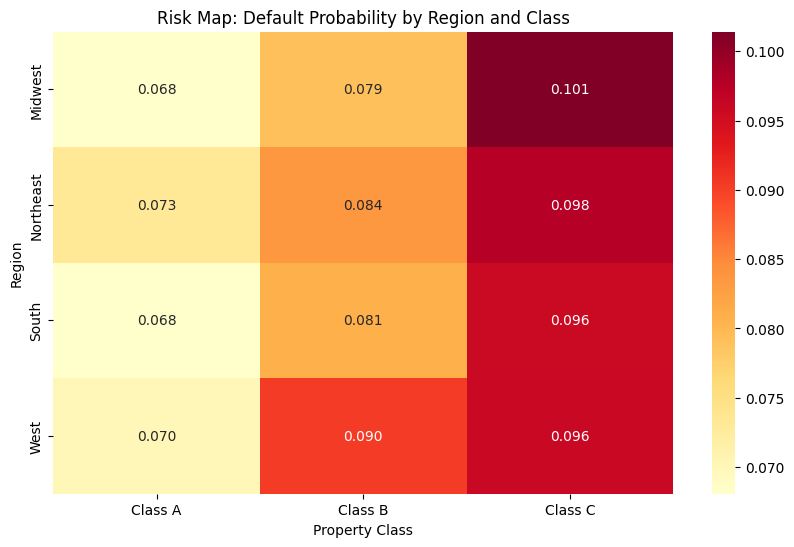

SUCESSO! O arquivo 'analise_risco_final.csv' foi criado.


In [ ]:
import pandas as pd
import re
import numpy as np
from sklearn.linear_model import LogisticRegression
import seaborn as sns        # <--- NOVO: Para o mapa de calor
import matplotlib.pyplot as plt # <--- NOVO: Para exibir o gráfico

df = pd.read_csv('Loan default case.csv')
df.columns = df.columns.str.strip()

# --- CLEANING FUNCTION ---
def total_clean(v):
    if pd.isna(v) or v == '': return 0.0
    v = str(v).strip().lower().replace('%', '').replace('r$', '').replace(',', '.')
    if v.count('.') > 1:
        partes = v.split('.')
        v = "".join(partes[:-1]) + "." + partes[-1]
    v = re.sub(r'[^\d.]', '', v)
    try:
        return float(v)
    except:
        return 0.0

numeric_cols = ['Original Loan Amount', 'Property value', 'Net operating income', 
                'Contractual term', 'Months to maturity', 'Annual tenant turnover', 
                'Interest rate', 'Default flag']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(total_clean)

# 3. Calculate LTV & DSCR
df['LTV'] = (df['Original Loan Amount'] / df['Property value'].replace(0, np.nan)) * 100
df['DSCR'] = df['Net operating income'] / df['Original Loan Amount'].replace(0, np.nan)
df[['LTV', 'DSCR']] = df[['LTV', 'DSCR']].fillna(0.0)

# --- 4. IMPROVED FLAG RULES ---
def define_flags(row):
    if row['Default flag'] == 1:
        return 'ALREADY DEFAULT'
    if row['LTV'] > 90: return 'Red Flag (Triple)'
    if row['DSCR'] < 0.3: return 'Red Flag (Double)'
    if row['Months to maturity'] < 6 and row['LTV'] > 90: return 'Red Flag (Quadruple)'
    if row['Annual tenant turnover'] > 17: return 'Red Flag (Double)'
    if row['LTV'] > 50: return 'Yellow Flag'
    if row['DSCR'] < 1: return 'Yellow Flag'
    if row['Months to maturity'] < 12 and row['LTV'] > 60: return 'Yellow Flag (Triple)'
    if row['Annual tenant turnover'] > 14: return 'Yellow Flag'
    return 'Green Flag'

df['Risk Status'] = df.apply(define_flags, axis=1)

#  5. LOGISTIC REGRESSION 
features = ['LTV', 'DSCR', 'Annual tenant turnover', 'Interest rate']
X = df[features].fillna(0.0)
y = df['Default flag'].fillna(0).astype(int)

model = LogisticRegression()
model.fit(X, y)
df['Prob_Default'] = model.predict_proba(X)[:, 1]

# --- 6. VISUAL HEATMAP ---
print("\n=== GENERATING RISK HEATMAP ===")
mapa_dados = df.pivot_table(index='Region', columns='Property Class', values='Prob_Default', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(mapa_dados, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('Risk Map: Default Probability by Region and Class')
plt.show()



In [1]:
import pandas as pd
import re
import numpy as np
from sklearn.linear_model import LogisticRegression

try:
    df = pd.read_csv('Loan default case.csv')
    df.columns = df.columns.str.strip()
    print("✅ File loaded successfully!")
except FileNotFoundError:
    print("❌ ERROR: The file 'Loan default case.csv' was not found in the folder.")
    raise

# --- DEFINITIVE CLEANING FUNCTION ---
def total_clean(v):
    if pd.isna(v) or v == '': return 0.0
    v = str(v).strip().lower().replace('%', '').replace('$', '').replace(',', '.')
    
    if v.count('.') > 1:
        parts = v.split('.')
        v = "".join(parts[:-1]) + "." + parts[-1]
    
    v = re.sub(r'[^\d.]', '', v)
    try:
        return float(v)
    except:
        return 0.0

# 2. Apply cleaning to numerical columns
numeric_cols = ['Original Loan Amount', 'Property value', 'Net operating income', 
                'Contractual term', 'Months to maturity', 'Annual tenant turnover', 
                'Interest rate', 'Default flag']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(total_clean)

# --- 3. METRICS CALCULATION ---
# LTV = (Original Loan / Property Value) * 100
df['LTV'] = (df['Original Loan Amount'] / df['Property value'].replace(0, np.nan)) * 100

# DSCR = NOI / Original Loan Amount
df['DSCR'] = df['Net operating income'] / df['Original Loan Amount'].replace(0, np.nan)

# Fill gaps generated by division by zero
df[['LTV', 'DSCR']] = df[['LTV', 'DSCR']].fillna(0.0)

# ---  RISK FLAG RULES (Preventive) ---
def define_flags(row):
    if row['Default flag'] == 1:
        return 'ALREADY DEFAULT'
    
    # RED FLAGS
    if row['LTV'] > 95: return 'Red Flag (Triple)'
    if row['DSCR'] < 0.2: return 'Red Flag (Double)'
    if row['Months to maturity'] < 6 and row['LTV'] > 90: return 'Red Flag (Quadruple)'
    if row['Annual tenant turnover'] > 17: return 'Red Flag (Double)'
    
    # YELLOW FLAGS
    if row['LTV'] > 50: return 'Yellow Flag'
    if row['DSCR'] < 1: return 'Yellow Flag'
    if row['Months to maturity'] < 12 and row['LTV'] > 60: return 'Yellow Flag (Triple)'
    if row['Annual tenant turnover'] > 14: return 'Yellow Flag'
    
    return 'Green Flag'

df['Risk Status'] = df.apply(define_flags, axis=1)

# LOGISTIC REGRESSION (Default Probability) 
features = ['LTV', 'DSCR', 'Annual tenant turnover', 'Interest rate']
X = df[features].fillna(0.0)
y = df['Default flag'].fillna(0).astype(int)

model = LogisticRegression()
model.fit(X, y)
df['Default_Prob'] = model.predict_proba(X)[:, 1]

#RISK MATRIX GENERATION (Heatmap Table)
risk_matrix = df.pivot_table(
    index='Region', 
    columns='Property Class', 
    values='Default_Prob', 
    aggfunc='mean'
)

print("\n=== RISK MATRIX (AVERAGE BY PROFILE) ===")
display(risk_matrix.round(4))

print("\n=== TOP 10 PREVENTIVE ALERTS (NON-DEFAULTERS) ===")
not_default = df[df['Default flag'] == 0]
display(not_default[['Region', 'Property Class', 'LTV', 'DSCR', 'Risk Status', 'Default_Prob']].sort_values(by='Default_Prob', ascending=False).head(10))

df.to_csv('complete_analysis_sheets.csv', index=False, sep=',', encoding='utf-8')
risk_matrix.to_json('risk_matrix.json', orient='index', indent=4)



✅ File loaded successfully!

=== RISK MATRIX (AVERAGE BY PROFILE) ===


Property Class,Class A,Class B,Class C
Region,,,
Midwest,0.0681,0.0791,0.1014
Northeast,0.0733,0.0836,0.0977
South,0.0682,0.0808,0.0958
West,0.0700,0.0904,0.0958



=== TOP 10 PREVENTIVE ALERTS (NON-DEFAULTERS) ===


,Region,Property Class,LTV,DSCR,Risk Status,Default_Prob
6604,Midwest,NaN,92.0,0.051413,Red Flag (Double),0.255252
740,Midwest,NaN,89.0,0.044382,Red Flag (Double),0.234944
1239,Midwest,Class C,90.0,0.057778,Red Flag (Double),0.230756
8624,South,NaN,89.0,0.076854,Red Flag (Double),0.219815
6011,West,Class B,83.0,0.025542,Red Flag (Double),0.214035
6710,Northeast,NaN,83.0,0.062410,Red Flag (Double),0.213254
3317,Northeast,NaN,84.0,0.062500,Red Flag (Double),0.210189
3551,South,Class C,82.0,0.006098,Red Flag (Double),0.210086
1643,Midwest,NaN,90.0,0.056444,Red Flag (Double),0.209056
340,Midwest,Class C,80.0,0.014125,Red Flag (Double),0.207682


In [2]:
%pip install seaborn matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 6.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.3 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 5.5 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 5.2 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 5.3 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---- -------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
